In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np

In [74]:
type_names = [
    "No Optimisations",
    "Adjoint Differentiation",
    "Adjoint Diff + JIT Compiled"]

df = pd.read_pickle("qaoa_runtimes3.pkl")

# Adjust for the incorrect initial labelling of the file types
df["NewFileType"] = df.FileType.map({"No JIT": type_names[0], "No Adjoint": type_names[1], "No Batching": type_names[2]}).astype("category")

# Adjust for the offset or running "No Batching" without Adjoint Differentiation, which was a mistake in the original data collection
# Take the difference between the times on "No Optimisations" and "Adjoint Differentiation" on each qubit count, and add this difference to the "No Batching" times
for qubits in df['Qubits'].unique():
    no_opt_time = df[(df['Qubits'] == qubits) & (df['NewFileType'] == type_names[0])]['Time (s)'].values[0]
    adjoint_time = df[(df['Qubits'] == qubits) & (df['NewFileType'] == type_names[1])]['Time (s)'].values[0]
    time_diff = (adjoint_time - no_opt_time)/ 5
    df.loc[(df['Qubits'] == qubits) & (df['NewFileType'] == type_names[2]), 'Time (s)'] += time_diff

# For our tests we used a smaller seed size 5 vs. 30 and a lessened epoch count 15 vs 150,
# We want to display the time it would've taken with the larger seed size and epoch count, so we will multiply the times by 60
df['Time (s)'] *= 60

# We have additive constants for the compilation time of the Baseline, Adjoint Differentiation, and JIT Compiled versions,

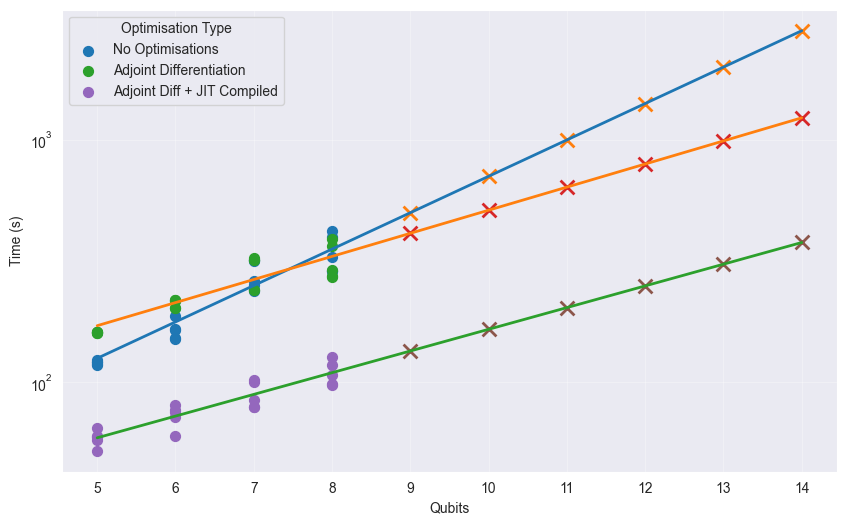

In [75]:
def exponential(x, a, b):
    return a * np.exp(b * x)

fig, ax = plt.subplots(figsize=(10, 6))

x_axis_vals = df['Qubits'].unique()
x_axis_vals.sort()

for name in type_names:
    subset = df[df['NewFileType'] == name]
    x_data = subset['Qubits'].values
    y_data = subset['Time (s)'].values

    # Fit exponential curve
    popt, _ = curve_fit(exponential, x_data, y_data, p0=[1, 0.1], maxfev=10000)

    ax.scatter(x_data, y_data, label=name, s=50)

    # Generate fitted curve and extrapolation
    x_fit = np.linspace(x_data.min(), 14, 100)
    y_fit = exponential(x_fit, *popt)
    ax.plot(x_fit, y_fit, linewidth=2)

    # Add extrapolated points for 9-14 qubits
    x_extrap = np.arange(9, 15)
    y_extrap = exponential(x_extrap, *popt)
    ax.scatter(x_extrap, y_extrap, marker='x', s=100, linewidths=2)


# sns.regplot(df, x="Qubits", y="Time (s)", ax=ax)
ax.set_yscale('log')
ax.set_xlabel('Qubits')
ax.set_ylabel('Time (s)')
ax.set_xticks(range(int(x_axis_vals.min()), 15))
ax.legend(title="Optimisation Type")
ax.grid(True, alpha=0.3)

plt.savefig(f"plots/runtimes_comparison_exrapolated.svg", dpi=300, bbox_inches='tight')

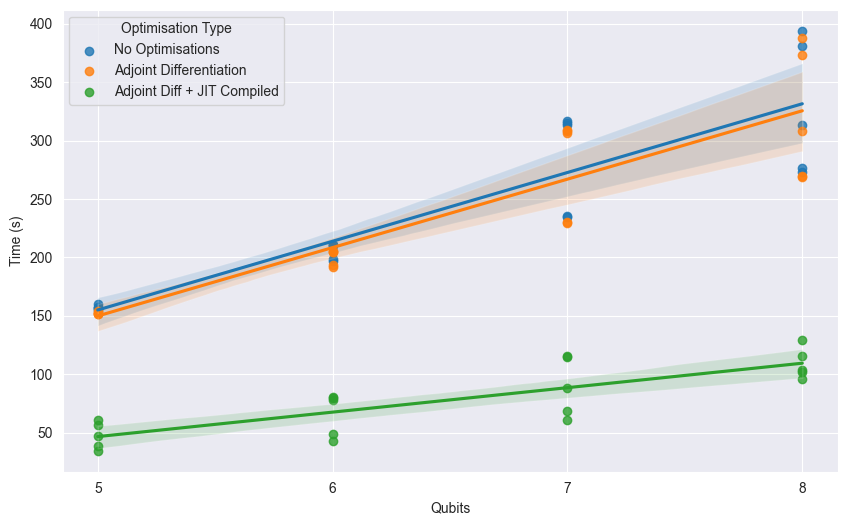

In [58]:
df2 = pd.read_pickle("qaoa_runtimes4.pkl")
# These datapoints are good
df2["NewFileType"] = df2.FileType.map({"No Adjoint": type_names[0], "No JIT": type_names[1], "No Batching": type_names[2]}).astype("category")
#delete items >= 9 Qubits
df2 = df2[df2['Qubits'] < 9]

fig, ax = plt.subplots(figsize=(10, 6))

x_axis_vals = df2['Qubits'].unique()
x_axis_vals.sort()

for name in type_names:
    subset = df2[df2['NewFileType'] == name]
    sns.regplot(subset, x="Qubits", y="Time (s)", ax=ax, label=name)

# sns.regplot(df, x="Qubits", y="Time (s)", ax=ax)
ax.set_xticks(x_axis_vals)
# ax.set_yscale('log')
ax.legend(title="Optimisation Type")

plt.savefig(f"plots/runtimes_comparison2.svg", dpi=300, bbox_inches='tight')